In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
import netCDF4  
import time
import utils as u

import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *

In [2]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]
domain = 'MARFed'

In [3]:
# Selection des données montagne vs plaine
alti_thrs = 1500

### MAR

In [4]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

In [5]:
#MAR dataset
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRf/spin2/work/monthly/'
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_GRf_2000-2023.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ZTQLEV=0).TTZ.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

dsF = dsF.sel(time=slice("2000-01-01", "2020-12-31"))

model1='MAR'
res1=str('5kmx5km')

In [6]:
# Enlever k pixels sur les contours
k=15
dsF=dsF.isel(X=slice(k, -k), Y=slice(k, -k))
ds_grF=ds_grF.isel(x=slice(k, -k), y=slice(k, -k))

lat_min=ds_grF.LAT.values.min()
lat_max=ds_grF.LAT.values.max()

lon_min=ds_grF.LON.values.min()
lon_max=ds_grF.LON.values.max()

# latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
# lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

In [7]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

Fedchenko domain
lon min 68.38813 lon max 76.27104
lat min 36.850964 lat max 40.733284


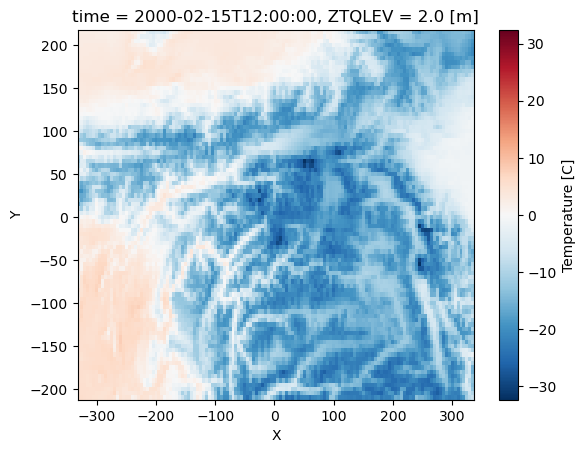

In [8]:
dsF.isel(time=1).plot()

In [49]:
ds_grF.SH>1000

<xarray.DataArray 'SH' (y: 86, x: 134)>
[11524 values with dtype=float32]
Coordinates:
  * x        (x) float32 -330.0 -325.0 -320.0 -315.0 ... 320.0 325.0 330.0 335.0
  * y        (y) float32 -210.0 -205.0 -200.0 -195.0 ... 200.0 205.0 210.0 215.0
Attributes:
    units:          m
    long_name:      Surface height
    standard_name:  Surface_height
    actual_range:   [ 249.11763 6131.6523 ]
    valid_range:    [-1.e+20  1.e+20]

# WORK in PROGRESS : comment extraire les données MAR pour SH > 1000 ?

In [52]:
dsF_sel = ds_grF.where(ds_grF.SH > 1000, drop=True)


In [53]:
dsF_sel 

<xarray.Dataset>
Dimensions:  (time: 1, y: 86, x: 134, sector: 2, soil: 7, level: 30)
Coordinates:
  * time     (time) datetime64[ns] 2000-01-01
  * x        (x) float32 -330.0 -325.0 -320.0 -315.0 ... 320.0 325.0 330.0 335.0
  * y        (y) float32 -210.0 -205.0 -200.0 -195.0 ... 200.0 205.0 210.0 215.0
  * level    (level) float32 0.03167 0.05017 0.0736 ... 0.999 0.9995 0.9997
  * sector   (sector) float32 1.0 2.0
  * soil     (soil) float32 1.0 2.0 3.0 4.0 5.0 6.0 7.0
Data variables: (12/40)
    DATE     (time, y, x) float32 nan nan nan nan ... 1.01e+04 1.01e+04 1.01e+04
    LON      (y, x) float32 nan nan nan nan nan ... 76.09 76.15 76.21 76.27
    LAT      (y, x) float32 nan nan nan nan nan ... 40.67 40.67 40.67 40.67
    SH       (y, x) float32 nan nan nan nan ... 3.557e+03 3.623e+03 3.771e+03
    SOL      (y, x) float32 nan nan nan nan nan nan ... 4.0 4.0 4.0 4.0 4.0 4.0
    TEX      (y, x) float32 nan nan nan nan nan nan ... 5.0 5.0 5.0 5.0 5.0 5.0
    ...       ...
    ZZ       (time, level, y, x) float32 nan nan nan ... 3.625e+03 3.773e+03
    SP       (time, y, x) float32 nan nan nan nan nan ... 66.4 65.97 65.41 64.16
    ST       (time, y, x) float32 nan nan nan nan ... 264.4 264.0 263.4 261.9
    SST      (time, y, x) float32 nan nan nan nan ... 264.4 264.0 263.4 261.9
    SIC      (time, y, x) float32 nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0
    EWC      (time, y, x) float32 nan nan nan nan ... 3.184 3.092 2.968 2.881
Attributes:
    title:        NESTOR output - Mod: MAR - Exp: GRf - 2000/01/01/00
    institution:  ULg (Xavier Fettweis)
    history:      libUN (2005.04.08) - Fri Apr 11 11:41:16 2025
    netcdf:       4.8.0 of May  2 2023 12:43:48 $

### ERA5

In [96]:
folder_era5='/bettik/PROJECTS/pr-regional-climate/fainx/era5/'

tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').t2m.load()-273.15
tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
tmp_era5 = tmp_era5.sel(time=slice("2000-01-01", "2020-12-31"))
tmp_era5 = tmp_era5.where((tmp_era5.lat >= lat_min) & (tmp_era5.lat <= lat_max), drop=True)
tmp_era5 = tmp_era5.where((tmp_era5.lon >= lon_min) & (tmp_era5.lon <= lon_max), drop=True)

model2='ERA5'
res2=str('31kmx31km')

(25, 49)


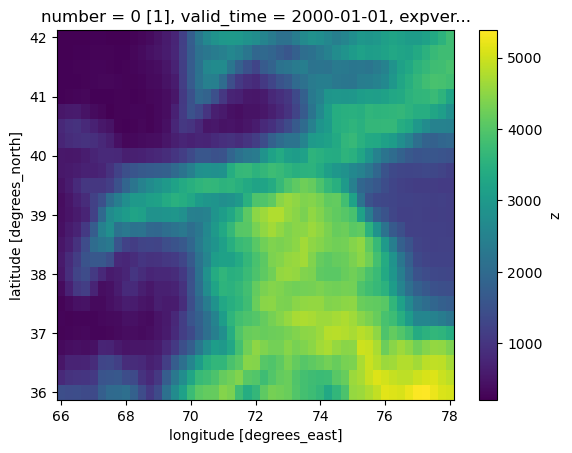

In [11]:
# ERA5 orography
orog_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5=orog_era5.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5.shape)
orog_era5[:,:].plot()

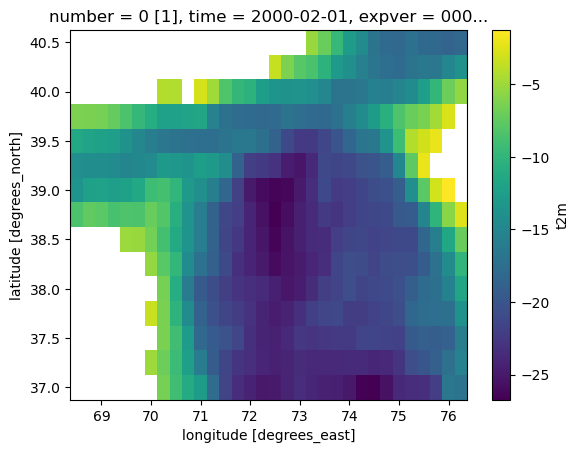

In [112]:
# Selection des données montagne vs plaine
orog_era5_on_tmp_grid = orog_era5.interp(
    lat=tmp_era5.lat,
    lon=tmp_era5.lon,
    method="linear"  
)

tmp_era5_high = tmp_era5.where(orog_era5_on_tmp_grid > alti_thrs)
tmp_era5_high.isel(time=1).plot()

### ERA5-land

In [117]:
folder_era5land='/bettik/PROJECTS/pr-regional-climate/fainx/era5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRf_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

tmp_era5land = tmp_era5land.sel(time=slice("2000-01-01", "2020-12-31"))
tmp_era5land = tmp_era5land.where((tmp_era5land.lat >= lat_min) & (tmp_era5land.lat <= lat_max), drop=True)
tmp_era5land = tmp_era5land.where((tmp_era5land.lon >= lon_min) & (tmp_era5land.lon <= lon_max), drop=True)

model3='ERA5-Land'
res3=str('0.1°x0.1°')

(61, 121)


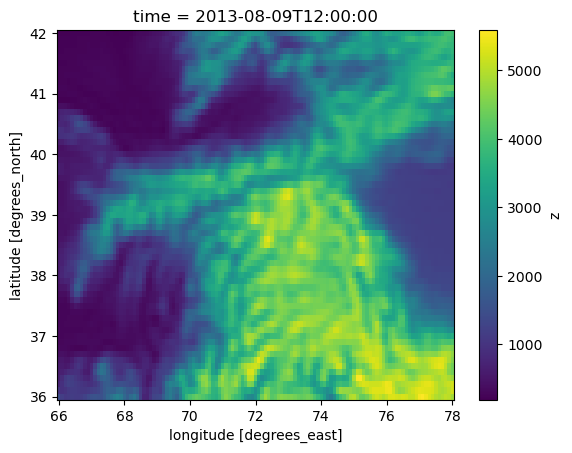

In [123]:
# ERA5-land orography
orog_era5land= xr.open_dataset(folder_era5land + 'geo.area-subset.42.78.36.66.nc').z.isel(time=0).load()/9.80665
orog_era5land=orog_era5land.rename({'latitude':'lat', 'longitude':'lon'})
print(orog_era5land.shape)
orog_era5land[:,:].plot()

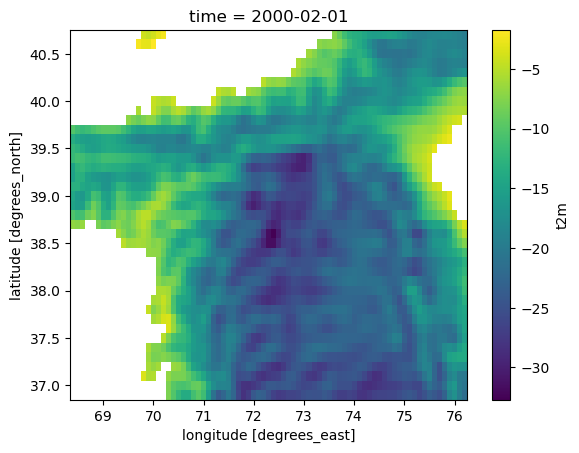

In [129]:
# Selection des données montagne vs plaine
orog_era5land_interp = orog_era5land.interp(
    lat=tmp_era5land.lat,
    lon=tmp_era5land.lon,
    method="linear"  
)

tmp_era5land_high = tmp_era5land.where(orog_era5land_interp > alti_thrs)
tmp_era5land_high
tmp_era5land_high.isel(time=1).plot()

### CRU

In [39]:
# Could to download latest version of CRU data
# 2021-2023 data missing

folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(folder_cru + 'cru_ts4.05.1901.2020.tmp.dat.nc').sel(lat=latlim_grF,lon=lonlim_grF).tmp.load()
tmp_cru=tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

model4='CRU'
res4=str('0.5°x0.5°')

/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/coding/times.py:154: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/nix/store/zc1wlsbnlcbacaiib6a5rgnf7fcjb9yc-python3-3.11.8-env/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to d

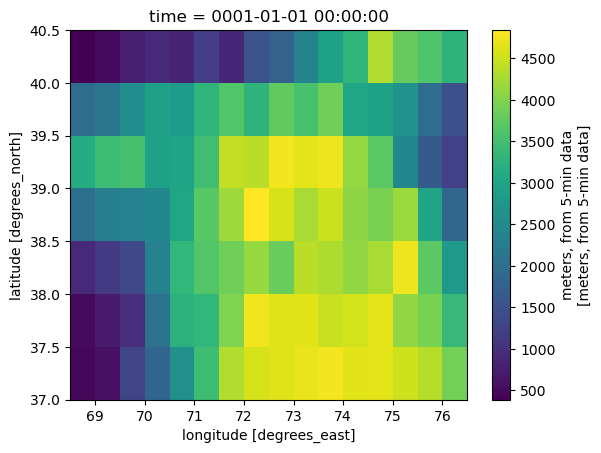

In [132]:
# JSIO orography for CRU
orog_jisao = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/jisao/' + 'jisao_elev.0.25-deg.nc').isel(time=0)

orog_cru=orog_jisao.interp(lat=tmp_cru.lat,lon=tmp_cru.lon)
orog_cru.data.plot()

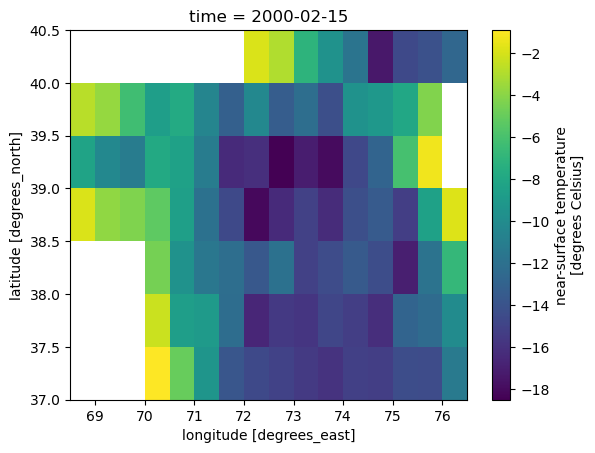

In [138]:
# Selection des données montagne vs plaine
orog_cru_interp = orog_cru.interp(
    lat=tmp_cru.lat,
    lon=tmp_cru.lon,
    method="linear"  
)

tmp_cru_high = tmp_cru.where(orog_cru_interp > alti_thrs)
tmp_cru_high
tmp_cru_high.data.isel(time=1).plot()

### HARv2

In [139]:
folder_HARv2='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
tmp_HARv2 = xr.open_mfdataset(folder_HARv2 + 'HARv2_mon_d10km_d_2d_t2_1980-2023.nc').t2.load()-273.15
tmp_HARv2= tmp_HARv2.sel(time=slice("2000-01-01", "2020-12-31"))

def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
      #  print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

tmp_HARv2=xy_sel_dom(tmp_HARv2,domain)
# tmp_HARv2=tmp_HARv2.sel(lat=latlim_grF,lon=lonlim_grF)

model5='HARv2'
res5=str('10kmx10km')

# WORK IN PROGRESS : comment selectionner les données HARv2 en altitude?

In [ ]:
modelList=[model1,model2,model3,model4,model5]
resList=[res1,res2,res3,res4,res5]
print(modelList)
print(resList)

## All altitudes included

In [ ]:
dsList=[dsF,tmp_era5, tmp_era5land, tmp_cru, tmp_HARv2]

In [ ]:
avgList=[]
for i,elem in enumerate(dsList):
    if i==0:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='lon').mean(dim='lat')
    elif i in [4]:
        print(i)
        print(modelList[i],resList[i])
        avg0=elem.mean(dim='west_east').mean(dim='south_north')
    avgList.append(avg0)



In [ ]:
annualCycleList = []

for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)

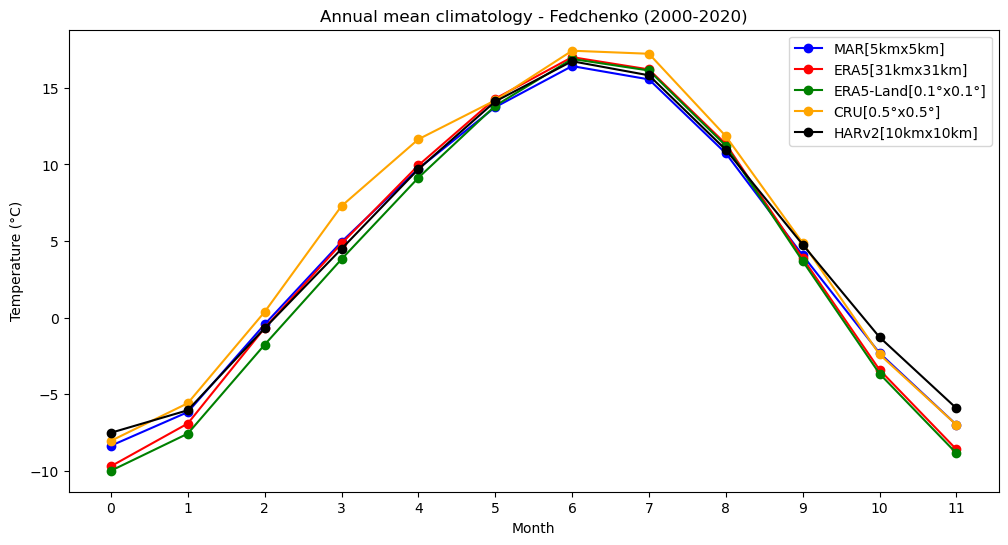

In [86]:
title="Annual mean climatology - Fedchenko (2000-2020)"

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(12, 6))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=modelList[0]+'['+ resList[0]+']')

ax.plot(xmonths, annualCycleList[1], 'r',linestyle='-',marker='o',label=modelList[1]+'['+ resList[1]+']')
ax.plot(xmonths, annualCycleList[2], 'g',linestyle='-',marker='o',label=modelList[2]+'['+ resList[2]+']')
ax.plot(xmonths, annualCycleList[3], 'orange',linestyle='-',marker='o',label=modelList[3]+'['+ resList[3]+']')
ax.plot(xmonths, annualCycleList[4], 'black',linestyle='-',marker='o',label=modelList[4]+'['+ resList[4]+']')


ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title(title)
freq=5
plt.xticks(xmonths,my_ticks,)
plt.legend()
plt.savefig('AnnualClimato_Fed.png',format='png')
plt.show()

## Only altitudes > 1500m included

In [140]:
dsList=[dsF_high,tmp_era5_high, tmp_era5land_high, tmp_cru_high]

NameError: name 'dsF_high' is not defined